# BERT Fine-Tuning, Logistic Regression & Linear SVM for Toxic Comment Detection
**WID3002 NLP Project — Toxic Comment Detector**

**⚠️ IMPORTANT: Set Runtime → Change runtime type → GPU (T4) before running.**

## 1. Setup & Install Dependencies

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

## 2 — DATA LOADING AND PREPROCESSING

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Dataset configuration
from google.colab import files

# Upload dataset file
uploaded = files.upload()

# Get uploaded filename
DATA_PATH = list(uploaded.keys())[0]

# Replace column names if different
TEXT_COLUMN = "tweet_text"
LABEL_COLUMN = "cyberbullying_type"

print(f"Uploaded file: {DATA_PATH}")

cuda


Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv
Uploaded file: cyberbullying_tweets.csv


In [ ]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nLabel distribution:')
print(df[LABEL_COLUMN].value_counts())

Shape: (47692, 2)

Label distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


Multi-class label distribution:
  not_cyberbullying (0): 7945 (16.7%)
  age (1): 7992 (16.8%)
  religion (2): 7998 (16.8%)
  gender (3): 7973 (16.7%)
  ethnicity (4): 7961 (16.7%)
  other_cyberbullying (5): 7823 (16.4%)


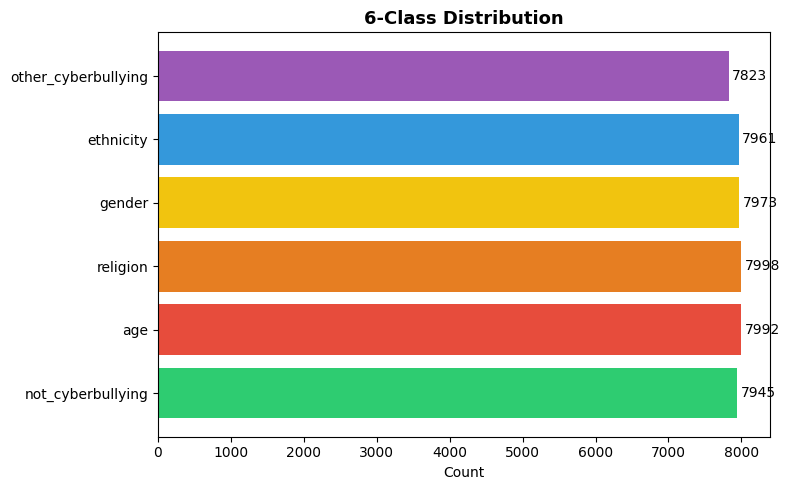

Train size: 33384
Validation size: 7154
Test size: 7154


In [ ]:
# === MULTI-CLASS LABEL MAPPING ===
LABEL_MAP = {
    "not_cyberbullying": 0,
    "age": 1,
    "religion": 2,
    "gender": 3,
    "ethnicity": 4,
    "other_cyberbullying": 5,
}
NUM_LABELS = 6
TARGET_NAMES = ["not_cyberbullying", "age", "religion", "gender", "ethnicity", "other_cyberbullying"]

def convert_label(label):
    return LABEL_MAP[label]

df["label"] = df[LABEL_COLUMN].apply(convert_label)

# Show distribution
print('Multi-class label distribution:')
for name, idx in LABEL_MAP.items():
    count = (df['label'] == idx).sum()
    print(f'  {name} ({idx}): {count} ({count/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
counts = df['label'].value_counts().sort_index()
colors_6 = ['#2ecc71','#e74c3c','#e67e22','#f1c40f','#3498db','#9b59b6']
labels_6 = [TARGET_NAMES[i] for i in counts.index]
ax.barh(labels_6, counts.values, color=colors_6)
ax.set_title('6-Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(counts.values):
    ax.text(v + 50, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()


# Minimal preprocessing for transformers
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

# TRAIN / VALIDATION / TEST SPLIT
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print(f"Train size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

## 3 — TOKENIZATION AND DATASET PREPARATION


In [ ]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

lengths = [
    len(tokenizer.encode(text, truncation=True, max_length=512))
    for text in train_texts
]

print(f"Average token length: {np.mean(lengths)}")
print(f"95th percentile: {np.percentile(lengths, 95)}")

MAX_LEN = 64

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = ToxicDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer, MAX_LEN)
test_dataset = ToxicDataset(test_texts, test_labels, tokenizer, MAX_LEN)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Average token length: 36.13278816199377
95th percentile: 69.0


## 4 — MODEL INITIALIZATION AND CLASS IMBALANCE HANDLING

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS  # Changed from 2 to 6
)

model.to(device)

# Compute class weights for all 6 classes
class_counts = []
for i in range(NUM_LABELS):
    class_counts.append(sum(train_labels == i))

class_weights = torch.tensor(
    [len(train_labels) / (NUM_LABELS * c) for c in class_counts],
    dtype=torch.float
).to(device)

print("Class weights:", class_weights)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

LR = 2e-5
EPOCHS = 8

optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: tensor([1.0005, 0.9946, 0.9937, 0.9970, 0.9984, 1.0161], device='cuda:0')


## 5 — TRAINING AND VALIDATION FUNCTIONS


In [ ]:
scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, dataloader):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

        total_loss += loss.item()
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

    return total_loss / len(dataloader)


def evaluate(model, dataloader):
    """Multi-class evaluation - no threshold needed."""
    model.eval()
    predictions = []
    all_probs = []
    true_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.cuda.amp.autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = loss_fn(logits, labels)

            total_loss += loss.item()
            probs = torch.softmax(logits.float(), dim=1)
            preds = torch.argmax(probs, dim=1)  # Multi-class: use argmax

            predictions.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    predictions = np.array(predictions)
    all_probs = np.array(all_probs)
    true_labels = np.array(true_labels)

    f1_macro = f1_score(true_labels, predictions, average='macro')
    f1_weighted = f1_score(true_labels, predictions, average='weighted')
    precision_macro = precision_score(true_labels, predictions, average='macro')
    recall_macro = recall_score(true_labels, predictions, average='macro')
    try:
        roc_auc = roc_auc_score(true_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        roc_auc = float('nan')

    return {
        'loss': total_loss / len(dataloader),
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'roc_auc': roc_auc,
        'predictions': predictions,
        'probabilities': all_probs,
        'true_labels': true_labels
    }

/tmp/ipykernel_2285/2761391041.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 6. Training Loop
This should take ~15-25 minutes on a T4 GPU for 8 epochs.

In [ ]:
best_f1 = 0
patience = 2
counter = 0
train_losses = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_epoch(model, train_loader)
    train_losses.append(train_loss)

    val_metrics = evaluate(model, val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_metrics['loss']:.4f}")
    print(f"Validation Precision (macro): {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall (macro): {val_metrics['recall_macro']:.4f}")
    print(f"Validation F1 (macro): {val_metrics['f1_macro']:.4f}")
    print(f"Validation F1 (weighted): {val_metrics['f1_weighted']:.4f}")
    print(f"Validation ROC-AUC (macro): {val_metrics['roc_auc']:.4f}")

    if val_metrics['f1_macro'] > best_f1:
        best_f1 = val_metrics['f1_macro']
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("Best model saved")
    else:
        counter += 1
        print(f"Early stopping counter: {counter}/{patience}")

    if counter >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(torch.load("best_model.pt"))
print("Best model loaded for final evaluation.")


Epoch 1/8


/tmp/ipykernel_2285/2761391041.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2285/2761391041.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.6702
Validation Loss: 0.4029
Validation Precision (macro): 0.8418
Validation Recall (macro): 0.8418
Validation F1 (macro): 0.8380
Validation F1 (weighted): 0.8387
Validation ROC-AUC (macro): 0.9713
Best model saved

Epoch 2/8


/tmp/ipykernel_2285/2761391041.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2285/2761391041.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.3688
Validation Loss: 0.3712
Validation Precision (macro): 0.8605
Validation Recall (macro): 0.8561
Validation F1 (macro): 0.8516
Validation F1 (weighted): 0.8522
Validation ROC-AUC (macro): 0.9751
Best model saved

Epoch 3/8


...

Train Loss: 0.2331
Validation Loss: 0.3678
Validation Precision (macro): 0.8644
Validation Recall (macro): 0.8628
Validation F1 (macro): 0.8624
Validation F1 (weighted): 0.8630
Validation ROC-AUC (macro): 0.9782
Early stopping counter: 1/2

Epoch 7/8


/tmp/ipykernel_2285/2761391041.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2285/2761391041.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.2168
Validation Loss: 0.3785
Validation Precision (macro): 0.8644
Validation Recall (macro): 0.8643
Validation F1 (macro): 0.8637
Validation F1 (weighted): 0.8643
Validation ROC-AUC (macro): 0.9781
Best model saved

Epoch 8/8


/tmp/ipykernel_2285/2761391041.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2285/2761391041.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.2036
Validation Loss: 0.3814
Validation Precision (macro): 0.8633
Validation Recall (macro): 0.8628
Validation F1 (macro): 0.8620
Validation F1 (weighted): 0.8626
Validation ROC-AUC (macro): 0.9781
Early stopping counter: 1/2
Best model loaded for final evaluation.


## 7. Final Test Evaluation and Performance Analysis

/tmp/ipykernel_2285/2761391041.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



FINAL TEST RESULTS (Multi-class)
Precision (macro): 0.8568
Recall (macro): 0.8557
F1-Score (macro): 0.8552
F1-Score (weighted): 0.8559
ROC-AUC (macro): 0.9765

Classification Report
                     precision  recall  f1-score   support
not_cyberbullying       0.6718  0.5872    0.6267 1192.0000
age                     0.9783  0.9758    0.9770 1199.0000
religion                0.9545  0.9608    0.9576 1200.0000
gender                  0.9001  0.8888    0.8944 1196.0000
ethnicity               0.9813  0.9690    0.9751 1194.0000
other_cyberbullying     0.6550  0.7528    0.7005 1173.0000
accuracy                0.8563  0.8563    0.8563    0.8563
macro avg               0.8568  0.8557    0.8552 7154.0000
weighted avg            0.8577  0.8563    0.8559 7154.0000


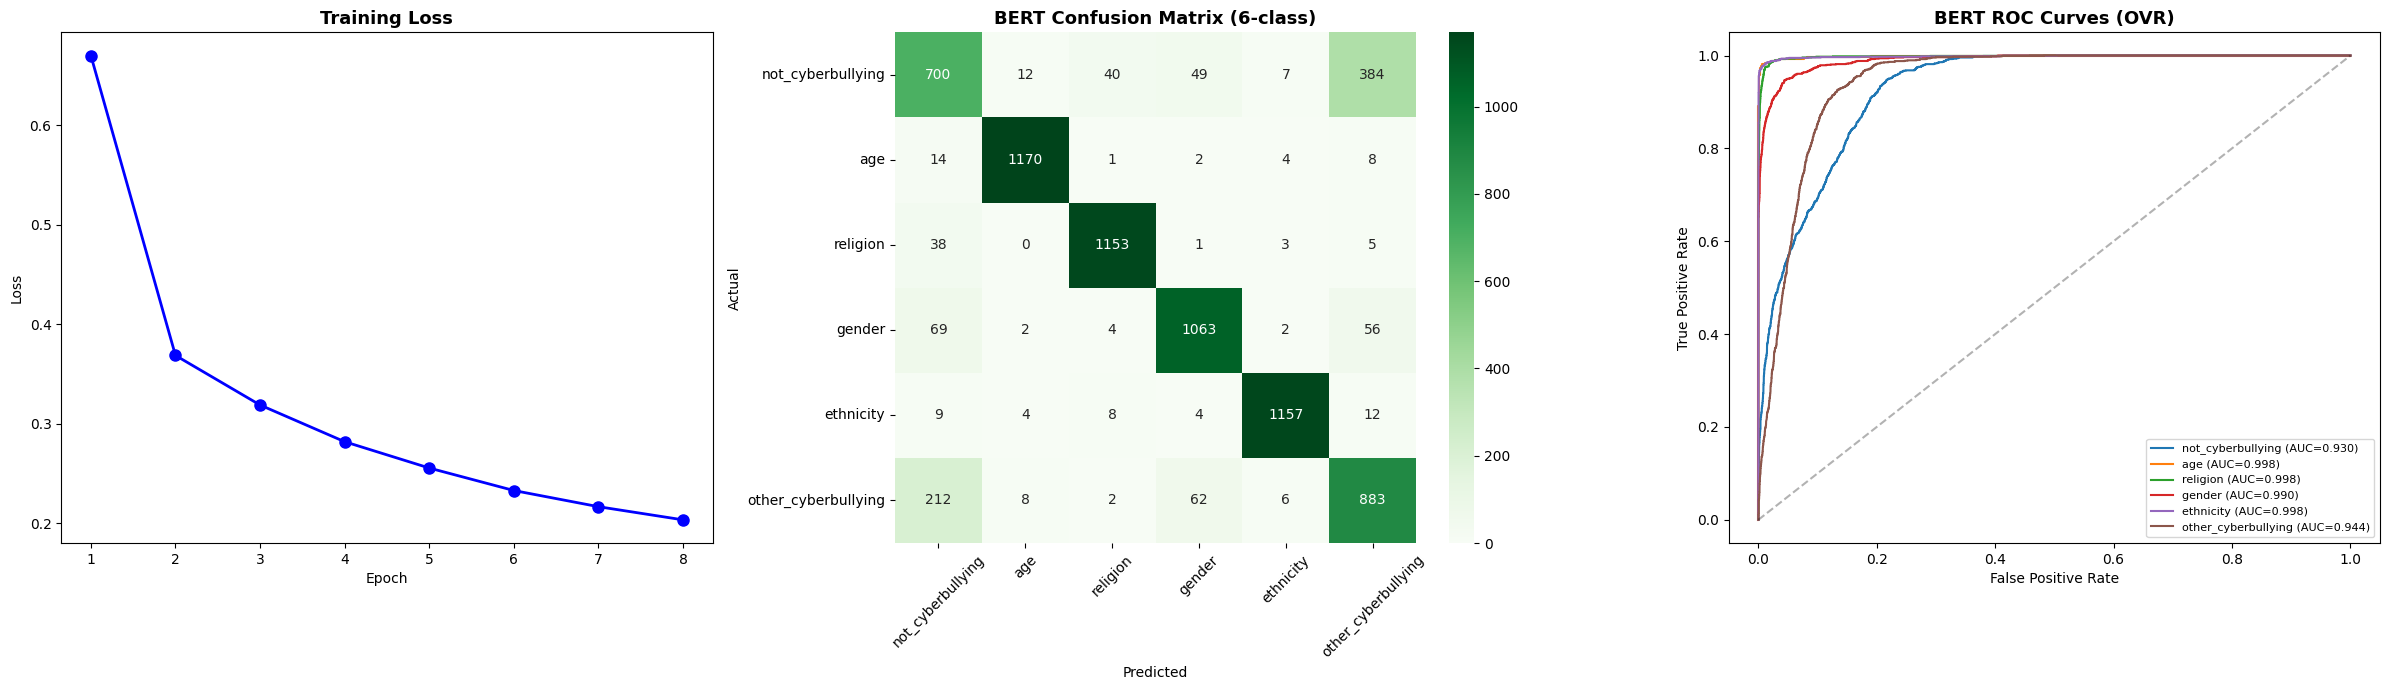


 Plots saved as bert_evaluation_multiclass.png


In [ ]:
final_metrics = evaluate(model, test_loader)

all_labels = np.array(final_metrics['true_labels'])
all_preds = np.array(final_metrics['predictions'])
all_probs = np.array(final_metrics['probabilities'])

print("\nFINAL TEST RESULTS (Multi-class)")
print(f"Precision (macro): {final_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {final_metrics['recall_macro']:.4f}")
print(f"F1-Score (macro): {final_metrics['f1_macro']:.4f}")
print(f"F1-Score (weighted): {final_metrics['f1_weighted']:.4f}")
print(f"ROC-AUC (macro): {final_metrics['roc_auc']:.4f}")

report = classification_report(
    all_labels,
    all_preds,
    target_names=TARGET_NAMES,
    digits=4,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report")
print(report_df.to_string(float_format='{:.4f}'.format))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Training loss curve
axes[0].plot(range(1, len(train_losses)+1), train_losses, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_xticks(range(1, len(train_losses)+1))

# Confusion matrix (6x6)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
axes[1].set_title('BERT Confusion Matrix (6-class)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

# ROC curves (one-vs-rest for each class)
labels_bin = label_binarize(all_labels, classes=list(range(NUM_LABELS)))
for i in range(NUM_LABELS):
    fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_i = roc_auc_score(labels_bin[:, i], all_probs[:, i])
    axes[2].plot(fpr_i, tpr_i, linewidth=1.5, label=f'{TARGET_NAMES[i]} (AUC={auc_i:.3f})')

axes[2].plot([0,1],[0,1],'k--', alpha=0.3)
axes[2].set_title('BERT ROC Curves (OVR)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('bert_evaluation_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Plots saved as bert_evaluation_multiclass.png')

---
# PHASE 2: Baseline Models
---

## i. Text Preprocessing
Clean tweets by removing URLs, mentions, hashtags, punctuation, numbers, and extra whitespace.

In [ ]:
df1 = pd.read_csv(DATA_PATH)
# Multi-class labels instead of binary
df1['label'] = df1['cyberbullying_type'].apply(lambda x: LABEL_MAP[x])

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'rt\s+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df1['cleaned_text'] = df1['tweet_text'].apply(clean_tweet)

print('Preprocessing examples:')
for i in range(5):
    print(f'\n  BEFORE: {df1["tweet_text"].iloc[i][:100]}')
    print(f'  AFTER:  {df1["cleaned_text"].iloc[i][:100]}')

empty = (df1['cleaned_text'].str.len() == 0).sum()
print(f'Empty tweets after cleaning: {empty}')
if empty > 0:
    df1 = df1[df1['cleaned_text'].str.len() > 0].reset_index(drop=True)
    print(f'   Removed. New shape: {df1.shape}')
else:
    print('   None found. No rows removed.')

Preprocessing examples:

  BEFORE: In other words #katandandre, your food was crapilicious! #mkr
  AFTER:  in other words katandandre your food was crapilicious mkr

  BEFORE: Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #Won
  AFTER:  why is aussietv so white mkr theblock imacelebrityau today sunrise studio neighbours wonderlandten e

  BEFORE: @XochitlSuckkks a classy whore? Or more red velvet cupcakes?
  AFTER:  a classy whore or more red velvet cupcakes

  BEFORE: @Jason_Gio meh. :P  thanks for the heads up, but not too concerned about another angry dude on twitt
  AFTER:  meh p thanks for the heads up but not too concerned about another angry dude on twitter

  BEFORE: @RudhoeEnglish This is an ISIS account pretending to be a Kurdish account.  Like Islam, it is all li
  AFTER:  this is an isis account pretending to be a kurdish account like islam it is all lies
Empty tweets after cleaning: 297
   Removed. New shape: (47395, 4)


## ii. Stratified Train-Test Split

In [ ]:
X = df1['cleaned_text']
y = df1['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Stratified Train/Validation/Test Split (70/15/15):')
print(f'   Train:      {len(X_train)} samples')
print(f'   Validation: {len(X_val)} samples')
print(f'   Test:       {len(X_test)} samples')
for name, idx in LABEL_MAP.items():
    print(f'   Train "{name}" ratio: {(y_train == idx).mean():.3f}')

Stratified Train/Validation/Test Split (70/15/15):
   Train:      33176 samples
   Validation: 7109 samples
   Test:       7110 samples
   Train "not_cyberbullying" ratio: 0.166
   Train "age" ratio: 0.169
   Train "religion" ratio: 0.169
   Train "gender" ratio: 0.168
   Train "ethnicity" ratio: 0.168
   Train "other_cyberbullying" ratio: 0.161


## iii. TF-IDF Feature Extraction

In [ ]:
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)
print(f'🔤 TF-IDF Vectorization:')
print(f'   Features (vocabulary size): {X_train_tfidf.shape[1]}')
print(f'   Train matrix shape:      {X_train_tfidf.shape}')
print(f'   Validation matrix shape: {X_val_tfidf.shape}')
print(f'   Test matrix shape:       {X_test_tfidf.shape}')

🔤 TF-IDF Vectorization:
   Features (vocabulary size): 30000
   Train matrix shape:      (33176, 30000)
   Validation matrix shape: (7109, 30000)
   Test matrix shape:       (7110, 30000)


## iv. Baseline Model 1: Logistic Regression
Using `class_weight='balanced'` to handle class imbalance (lecturer feedback #2).

In [ ]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)  # Full probability matrix

print('=' * 60)
print('LOGISTIC REGRESSION (Multi-class, class_weight="balanced")')
print('=' * 60)
print(classification_report(y_test, y_pred_lr, target_names=TARGET_NAMES))
try:
    lr_auc = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', average='macro')
    print(f'ROC-AUC (macro, OVR): {lr_auc:.4f}')
except ValueError as e:
    print(f'ROC-AUC: N/A ({e})')
    lr_auc = float('nan')

LOGISTIC REGRESSION (Multi-class, class_weight="balanced")
                     precision    recall  f1-score   support

  not_cyberbullying       0.59      0.56      0.58      1178
                age       0.96      0.96      0.96      1199
           religion       0.93      0.94      0.94      1200
             gender       0.92      0.81      0.86      1193
          ethnicity       0.97      0.97      0.97      1194
other_cyberbullying       0.59      0.68      0.63      1146

           accuracy                           0.82      7110
          macro avg       0.83      0.82      0.82      7110
       weighted avg       0.83      0.82      0.83      7110

ROC-AUC (macro, OVR): 0.9685


## v. Baseline Model 2: Linear SVM
Also using `class_weight='balanced'`.

In [ ]:
from scipy.special import softmax as scipy_softmax

svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
y_score_svm_raw = svm.decision_function(X_test_tfidf)  # raw margins, not probabilities
y_score_svm = scipy_softmax(y_score_svm_raw, axis=1)  # normalize to probability-like scores

print('=' * 60)
print('LINEAR SVM (Multi-class, class_weight="balanced")')
print('=' * 60)
print(classification_report(y_test, y_pred_svm, target_names=TARGET_NAMES))
try:
    svm_auc = roc_auc_score(y_test, y_score_svm, multi_class='ovr', average='macro')
    print(f'ROC-AUC (macro, OVR): {svm_auc:.4f}')
except ValueError as e:
    print(f'ROC-AUC: N/A ({e})')
    svm_auc = float('nan')

LINEAR SVM (Multi-class, class_weight="balanced")
                     precision    recall  f1-score   support

  not_cyberbullying       0.56      0.55      0.56      1178
                age       0.96      0.97      0.97      1199
           religion       0.94      0.95      0.95      1200
             gender       0.90      0.83      0.86      1193
          ethnicity       0.97      0.98      0.98      1194
other_cyberbullying       0.58      0.61      0.59      1146

           accuracy                           0.82      7110
          macro avg       0.82      0.82      0.82      7110
       weighted avg       0.82      0.82      0.82      7110

ROC-AUC (macro, OVR): 0.9617


## vi. Evaluation: Confusion Matrices & ROC Curves

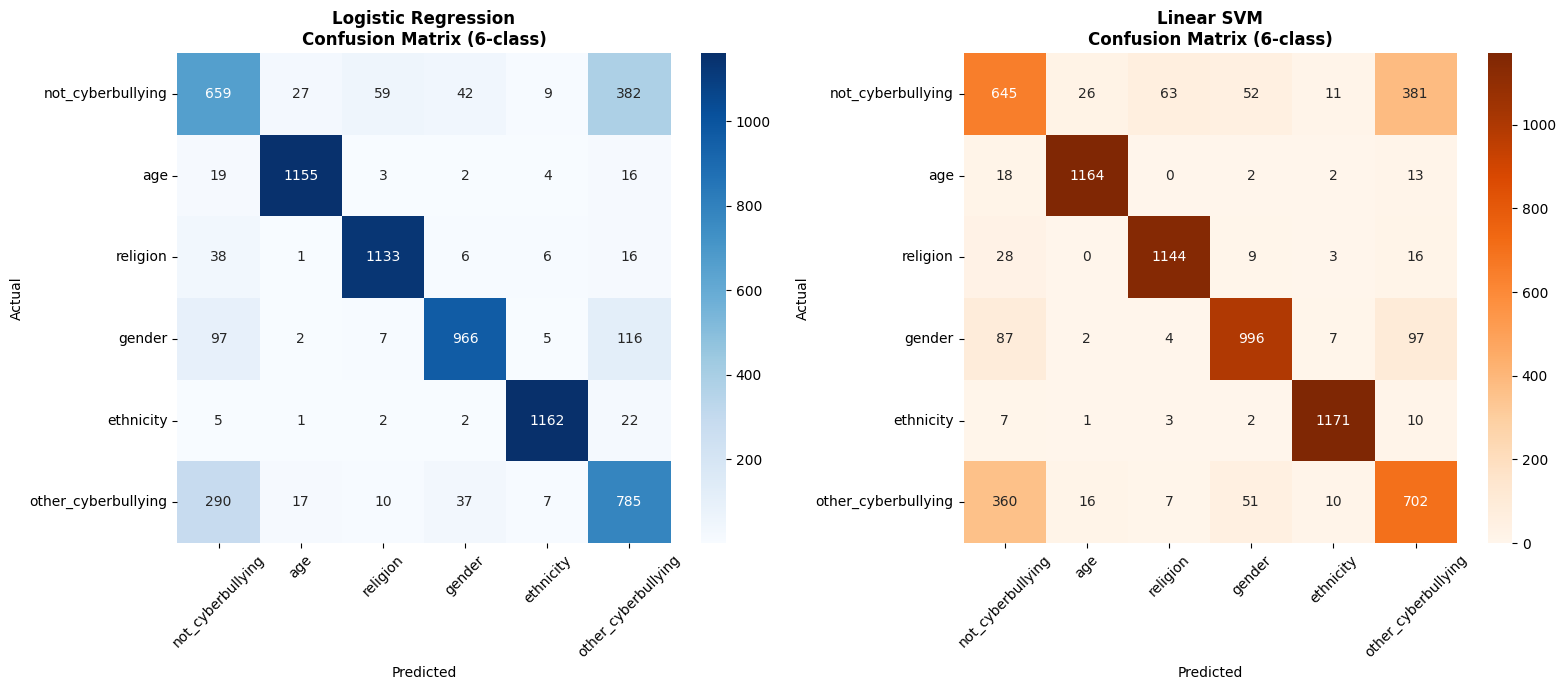

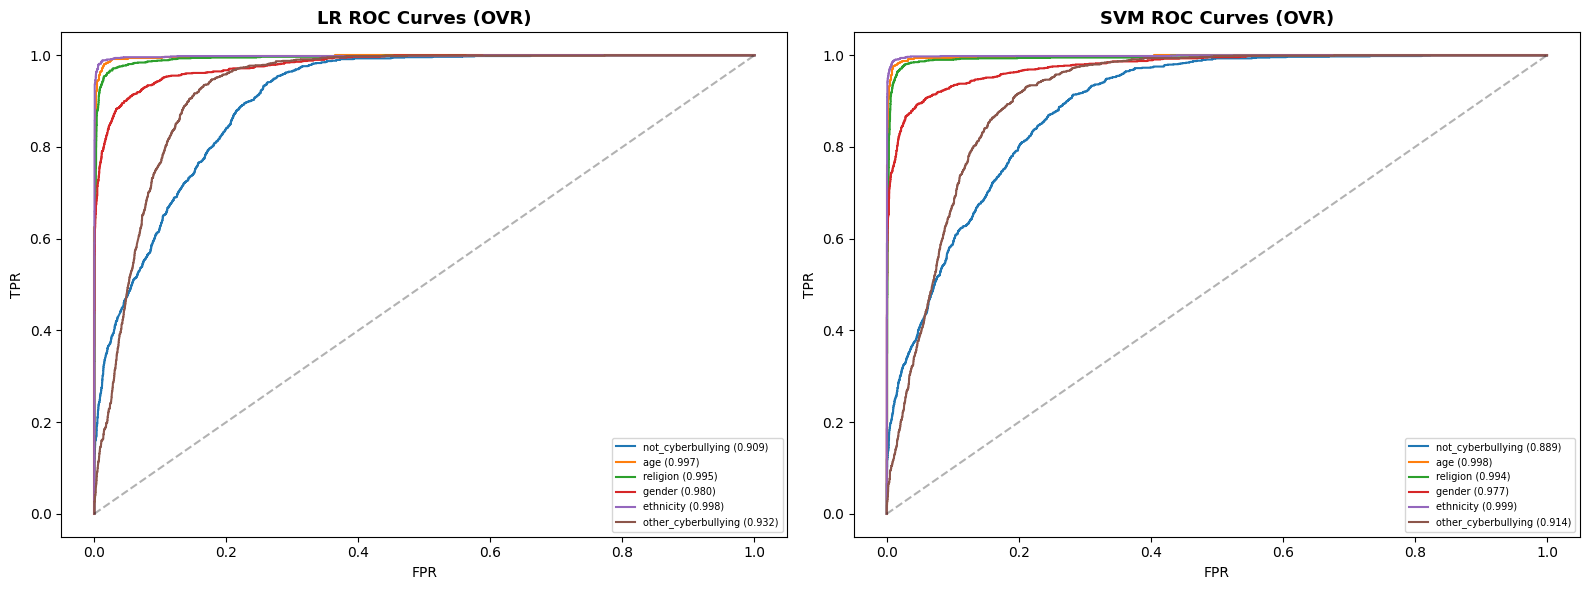

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# LR confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
axes[0].set_title('Logistic Regression\nConfusion Matrix (6-class)', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# SVM confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
axes[1].set_title('Linear SVM\nConfusion Matrix (6-class)', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


# ROC Curves for baselines
y_test_bin = label_binarize(y_test, classes=list(range(NUM_LABELS)))

fig, axes_roc = plt.subplots(1, 2, figsize=(16, 6))

# LR ROC
for i in range(NUM_LABELS):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob_lr[:, i])
    axes_roc[0].plot(fpr_i, tpr_i, linewidth=1.5, label=f'{TARGET_NAMES[i]} ({auc_i:.3f})')
axes_roc[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes_roc[0].set_title('LR ROC Curves (OVR)', fontsize=13, fontweight='bold')
axes_roc[0].set_xlabel('FPR'); axes_roc[0].set_ylabel('TPR')
axes_roc[0].legend(fontsize=7)

# SVM ROC
for i in range(NUM_LABELS):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_score_svm[:, i])
    axes_roc[1].plot(fpr_i, tpr_i, linewidth=1.5, label=f'{TARGET_NAMES[i]} ({auc_i:.3f})')
axes_roc[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes_roc[1].set_title('SVM ROC Curves (OVR)', fontsize=13, fontweight='bold')
axes_roc[1].set_xlabel('FPR'); axes_roc[1].set_ylabel('TPR')
axes_roc[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## v. Summary

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ],
    'ROC-AUC (macro)': [lr_auc, svm_auc]
})

print('=' * 60)
print('BASELINE MODELS SUMMARY (6-class)')
print('=' * 60)
print(summary.to_string(index=False, float_format='{:.4f}'.format))
print('\nPhase 1 & 2 complete.')

BASELINE MODELS SUMMARY (6-class)
              Model  Accuracy  Macro F1  Weighted F1  ROC-AUC (macro)
Logistic Regression    0.8242    0.8237       0.8258           0.9685
         Linear SVM    0.8188    0.8169       0.8192           0.9617

Phase 1 & 2 complete.


## Model Comparision

MODEL COMPARISON: BERT vs Baselines (6-class)
              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)  ROC-AUC (macro)
  BERT (Fine-tuned)    0.8563             0.8568          0.8557      0.8552         0.8559           0.9765
Logistic Regression    0.8242             0.8275          0.8225      0.8237         0.8258           0.9685
         Linear SVM    0.8188             0.8179          0.8166      0.8169         0.8192           0.9617


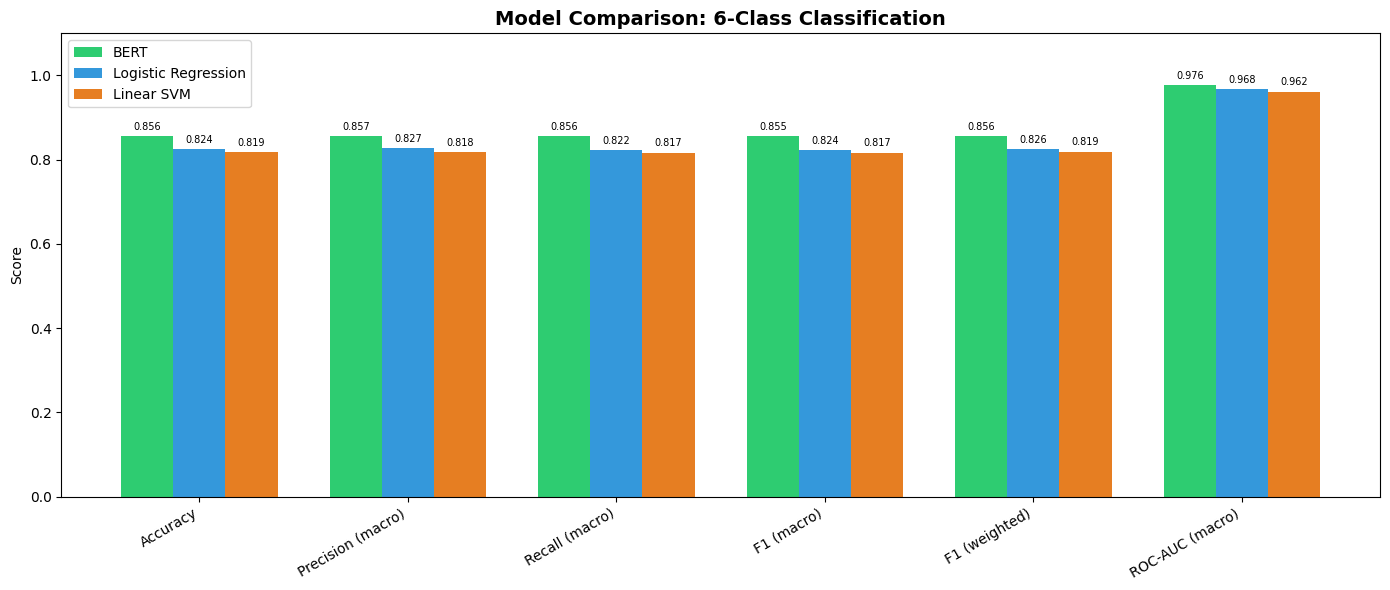


Model comparison chart saved.


In [ ]:
# BERT metrics (from final_metrics computed above)
bert_accuracy = accuracy_score(all_labels, all_preds)
bert_precision = precision_score(all_labels, all_preds, average='macro')
bert_recall = recall_score(all_labels, all_preds, average='macro')
bert_f1_macro = f1_score(all_labels, all_preds, average='macro')
bert_f1_weighted = f1_score(all_labels, all_preds, average='weighted')
try:
    bert_roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
except:
    bert_roc_auc = float('nan')

# LR metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='macro')
lr_recall = recall_score(y_test, y_pred_lr, average='macro')
lr_f1_macro = f1_score(y_test, y_pred_lr, average='macro')
lr_f1_weighted = f1_score(y_test, y_pred_lr, average='weighted')

# SVM metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_f1_macro = f1_score(y_test, y_pred_svm, average='macro')
svm_f1_weighted = f1_score(y_test, y_pred_svm, average='weighted')

comparison = pd.DataFrame({
    'Model': ['BERT (Fine-tuned)', 'Logistic Regression', 'Linear SVM'],
    'Accuracy': [bert_accuracy, lr_accuracy, svm_accuracy],
    'Precision (macro)': [bert_precision, lr_precision, svm_precision],
    'Recall (macro)': [bert_recall, lr_recall, svm_recall],
    'F1 (macro)': [bert_f1_macro, lr_f1_macro, svm_f1_macro],
    'F1 (weighted)': [bert_f1_weighted, lr_f1_weighted, svm_f1_weighted],
    'ROC-AUC (macro)': [bert_roc_auc, lr_auc, svm_auc]
})

print('=' * 80)
print('MODEL COMPARISON: BERT vs Baselines (6-class)')
print('=' * 80)
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

# Comparison bar chart
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'F1 (weighted)', 'ROC-AUC (macro)']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bert_vals = [comparison.loc[0, m] for m in metrics_to_plot]
lr_vals = [comparison.loc[1, m] for m in metrics_to_plot]
svm_vals = [comparison.loc[2, m] for m in metrics_to_plot]

bars1 = ax.bar(x - width, bert_vals, width, label='BERT', color='#2ecc71')
bars2 = ax.bar(x, lr_vals, width, label='Logistic Regression', color='#3498db')
bars3 = ax.bar(x + width, svm_vals, width, label='Linear SVM', color='#e67e22')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: 6-Class Classification', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nModel comparison chart saved.')

## Export All Models

In [ ]:
import joblib
import json
import os

# Create export directory
EXPORT_DIR = "exported_models"
os.makedirs(EXPORT_DIR, exist_ok=True)

# --- 1. Save BERT model (full model + tokenizer) ---
# Save the fine-tuned BERT model weights
bert_save_path = os.path.join(EXPORT_DIR, "bert_model.pt")
torch.save(model.state_dict(), bert_save_path)
print(f"BERT model weights saved to: {bert_save_path}")

# Save the tokenizer (needed to preprocess text the same way during inference)
tokenizer_save_path = os.path.join(EXPORT_DIR, "bert_tokenizer")
tokenizer.save_pretrained(tokenizer_save_path)
print(f"BERT tokenizer saved to: {tokenizer_save_path}/")

# --- 2. Save Logistic Regression model ---
lr_save_path = os.path.join(EXPORT_DIR, "logistic_regression.pkl")
joblib.dump(lr, lr_save_path)
print(f"Logistic Regression model saved to: {lr_save_path}")

# --- 3. Save Linear SVM model ---
svm_save_path = os.path.join(EXPORT_DIR, "linear_svm.pkl")
joblib.dump(svm, svm_save_path)
print(f"Linear SVM model saved to: {svm_save_path}")

# --- 4. Save TF-IDF Vectorizer (shared by LR and SVM) ---
tfidf_save_path = os.path.join(EXPORT_DIR, "tfidf_vectorizer.pkl")
joblib.dump(tfidf, tfidf_save_path)
print(f"TF-IDF Vectorizer saved to: {tfidf_save_path}")

# --- 5. Save label metadata (label map, target names, model config) ---
metadata = {
    "label_map": LABEL_MAP,
    "target_names": TARGET_NAMES,
    "num_labels": NUM_LABELS,
    "bert_model_name": MODEL_NAME,
    "max_len": MAX_LEN,
}
metadata_save_path = os.path.join(EXPORT_DIR, "model_metadata.json")
with open(metadata_save_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Model metadata saved to: {metadata_save_path}")

print("\n" + "=" * 60)
print("ALL MODELS EXPORTED SUCCESSFULLY")
print("=" * 60)
print(f"\nExported files in '{EXPORT_DIR}/':")
for fname in sorted(os.listdir(EXPORT_DIR)):
    fpath = os.path.join(EXPORT_DIR, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"  {fname:40s} ({size_mb:.2f} MB)")
    else:
        print(f"  {fname:40s} (directory)")

BERT model weights saved to: exported_models/bert_model.pt
BERT tokenizer saved to: exported_models/bert_tokenizer/
Logistic Regression model saved to: exported_models/logistic_regression.pkl
Linear SVM model saved to: exported_models/linear_svm.pkl
TF-IDF Vectorizer saved to: exported_models/tfidf_vectorizer.pkl
Model metadata saved to: exported_models/model_metadata.json

ALL MODELS EXPORTED SUCCESSFULLY

Exported files in 'exported_models/':
  bert_model.pt                            (417.74 MB)
  bert_tokenizer                           (directory)
  linear_svm.pkl                           (1.37 MB)
  logistic_regression.pkl                  (1.37 MB)
  model_metadata.json                      (0.00 MB)
  tfidf_vectorizer.pkl                     (1.10 MB)


In [ ]:
import shutil

# Zip the entire export directory
zip_path = shutil.make_archive("exported_models", "zip", ".", EXPORT_DIR)
print(f"Zipped all models to: {zip_path}")

# Trigger download in Colab
files.download(zip_path)
print("Download started! Save this zip and extract it into your web app project folder.")

Zipped all models to: /content/exported_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Save this zip and extract it into your web app project folder.
